# Recommendation System: Content-Based vs. Collaborative Filtering

**Name:** MD. Shafiqul Islam &nbsp;&nbsp; **Student ID:** 905253024

This notebook covers Deliverables 1 and 2, built on a self-generated synthetic catalog
(`recommendation_system_dataset_v2.xlsx`) with the same structure as the course dataset
(60 items across 6 categories, 3,460 ratings from 300 users):

- Part 1 — Data exploration
- Part 2 — Content-based filtering (TF-IDF + cosine similarity)
- Part 3 — Collaborative filtering: user-based, and matrix factorization (Truncated SVD)
- Part 4 — Additional variation: item-based collaborative filtering
- Part 5 — Evaluation and model comparison
- Part 6 — Cold-start cases: a brand-new item and a brand-new user


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "DejaVu Serif"
os.makedirs("outputs", exist_ok=True)

items = pd.read_excel("../data/recommendation_system_dataset_v2.xlsx", sheet_name="Items")
ratings = pd.read_excel("../data/recommendation_system_dataset_v2.xlsx", sheet_name="Ratings", parse_dates=["timestamp"])

print("Items:", items.shape, "  Ratings:", ratings.shape)
items.head()

Items: (60, 6)   Ratings: (3460, 4)


,item_id,title,category,tags,price,description
0,1,Wireless Earbuds Pro,Tech & Gadgets,wireless bluetooth audio earbuds noise-cancelling,59.99,Wireless Earbuds Pro. wireless bluetooth audio...
1,2,Smart Fitness Band,Tech & Gadgets,wearable tracker heart-rate steps sleep,34.50,Smart Fitness Band. wearable tracker heart rat...
2,3,Portable Power Bank 20000mAh,Tech & Gadgets,charger battery portable usb-c fast-charging,28.00,Portable Power Bank 20000mAh. charger battery ...
3,4,Mechanical Keyboard,Tech & Gadgets,keyboard mechanical rgb gaming typing,79.99,Mechanical Keyboard. keyboard mechanical rgb g...
4,5,4K Webcam,Tech & Gadgets,webcam video camera streaming hd,45.00,4K Webcam. webcam video camera streaming hd. C...


## Part 1 — Exploring the Catalog and Ratings

Checking: how many items per category, how many
ratings per user, and how sparse the user–item matrix actually is — sparsity is the whole
reason collaborative filtering is a hard problem in the first place.

Items per category:
category
Tech & Gadgets         10
Outdoor & Camping      10
Kitchen & Dining       10
Fitness & Wellness     10
Books & Media          10
Office & Stationery    10
Name: count, dtype: int64


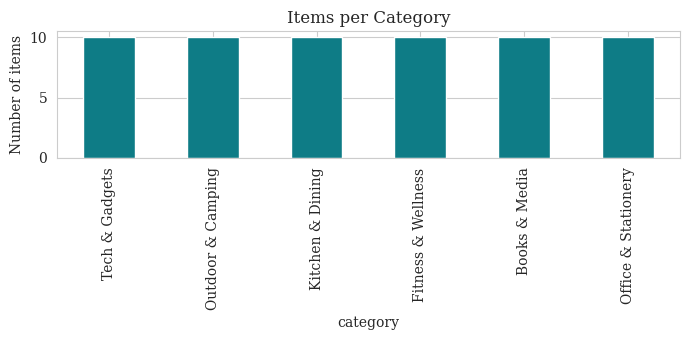

In [38]:
print("Items per category:")
print(items["category"].value_counts())

items["category"].value_counts().plot.bar(figsize=(7, 3.5), color="#0E7C86", title="Items per Category")
plt.ylabel("Number of items")
plt.tight_layout()
plt.savefig("../outputs/items_per_category.png", dpi=120)
plt.show()

Users: 300   Items rated: 59 (of 60 total)
Ratings per user  -- mean: 11.5, min: 1, max: 19
Ratings per item  -- mean: 58.6, min: 44, max: 76
User-item matrix sparsity: 80.8% empty


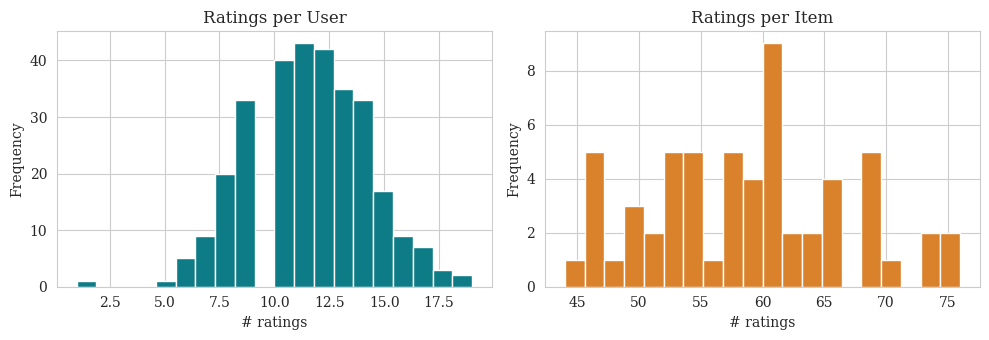

In [39]:
ratings_per_user = ratings.groupby("user_id").size()
ratings_per_item = ratings.groupby("item_id").size()

print(f"Users: {ratings['user_id'].nunique()}   Items rated: {ratings['item_id'].nunique()} (of {items.shape[0]} total)")
print(f"Ratings per user  -- mean: {ratings_per_user.mean():.1f}, min: {ratings_per_user.min()}, max: {ratings_per_user.max()}")
print(f"Ratings per item  -- mean: {ratings_per_item.mean():.1f}, min: {ratings_per_item.min()}, max: {ratings_per_item.max()}")

n_users = ratings["user_id"].nunique()
n_items = items.shape[0]
sparsity = 1 - len(ratings) / (n_users * n_items)
print(f"User-item matrix sparsity: {sparsity:.1%} empty")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
ratings_per_user.plot.hist(bins=20, ax=axes[0], color="#0E7C86")
axes[0].set_title("Ratings per User"); axes[0].set_xlabel("# ratings")
ratings_per_item.plot.hist(bins=20, ax=axes[1], color="#D9822B")
axes[1].set_title("Ratings per Item"); axes[1].set_xlabel("# ratings")
plt.tight_layout()
plt.savefig("../outputs/ratings_distributions.png", dpi=120)
plt.show()

## Part 2 — Content-Based Filtering (TF-IDF + Cosine Similarity)

Each item is represented by the text in its description (which includes its tags and
category). TF-IDF converts that text into numeric vectors, and cosine similarity finds
items with the most similar vectors — i.e. items that "talk about" similar things. This
approach needs no rating history at all for the item being compared, which is exactly why
it can handle a brand-new item with zero ratings (see Part 6).

In [40]:
tfidf = TfidfVectorizer(stop_words="english")
item_vectors = tfidf.fit_transform(items["description"])
print("TF-IDF matrix shape:", item_vectors.shape)

item_sim = cosine_similarity(item_vectors)
item_sim_df = pd.DataFrame(item_sim, index=items["item_id"], columns=items["item_id"])
item_sim_df.iloc[:5, :5]

TF-IDF matrix shape: (60, 260)


item_id,1,2,3,4,5
item_id,,,,,
1,1.000000,0.077417,0.069378,0.066872,0.074040
2,0.077417,1.000000,0.081951,0.078990,0.087457
3,0.069378,0.081951,1.000000,0.070788,0.078376
4,0.066872,0.078990,0.070788,1.000000,0.075545
5,0.074040,0.087457,0.078376,0.075545,1.000000


In [41]:
def content_based_recommend(item_id, top_n=5):
    scores = item_sim_df.loc[item_id].drop(item_id).sort_values(ascending=False)
    top_ids = scores.head(top_n).index
    result = items[items["item_id"].isin(top_ids)][["item_id", "title", "category"]].copy()
    result["similarity"] = scores.loc[top_ids].values
    return result.sort_values("similarity", ascending=False)

seed_item = items.iloc[0]
print(f"Seed item: {seed_item['title']} ({seed_item['category']})")
content_based_recommend(seed_item["item_id"], top_n=5)

Seed item: Wireless Earbuds Pro (Tech & Gadgets)


,item_id,title,category,similarity
1,2,Smart Fitness Band,Tech & Gadgets,0.367918
4,5,4K Webcam,Tech & Gadgets,0.270393
5,6,Bluetooth Speaker Mini,Tech & Gadgets,0.269027
8,9,Noise-Cancelling Headphones,Tech & Gadgets,0.077417
56,57,Wireless Mouse Ergonomic,Office & Stationery,0.074040


## Part 3 — Collaborative Filtering

### 3a. User-based collaborative filtering

Build a user×item ratings matrix, measure how similar users are to each other using
cosine similarity on their rating patterns, then recommend items that a target user's
most similar neighbors rated highly but the target user hasn't rated yet.

In [42]:
user_item = ratings.pivot_table(index="user_id", columns="item_id", values="rating")
print("User-item matrix shape:", user_item.shape)
user_item.iloc[:5, :8]

User-item matrix shape: (300, 59)


item_id,1,2,3,4,5,6,7,8
user_id,,,,,,,,
1,3.0,NaN,4.0,NaN,NaN,3.0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
filled = user_item.fillna(0)
user_sim = cosine_similarity(filled)
user_sim_df = pd.DataFrame(user_sim, index=user_item.index, columns=user_item.index)

def collaborative_recommend_user_based(user_id, top_n=5, k_neighbors=15):
    sims = user_sim_df.loc[user_id].drop(user_id).sort_values(ascending=False).head(k_neighbors)
    neighbor_ratings = user_item.loc[sims.index]
    weighted = neighbor_ratings.mul(sims, axis=0).sum(axis=0)
    weights = neighbor_ratings.notna().mul(sims, axis=0).sum(axis=0)
    scores = (weighted / weights.replace(0, np.nan)).dropna()

    already_rated = user_item.loc[user_id].dropna().index
    scores = scores.drop(index=already_rated, errors="ignore").sort_values(ascending=False)

    top_ids = scores.head(top_n).index
    result = items[items["item_id"].isin(top_ids)][["item_id", "title", "category"]].copy()
    result["predicted_rating"] = scores.loc[top_ids].values
    return result.sort_values("predicted_rating", ascending=False)

target_user = 1
collaborative_recommend_user_based(target_user, top_n=5)

,item_id,title,category,predicted_rating
3,4,Mechanical Keyboard,Tech & Gadgets,5.000000
25,26,Digital Kitchen Scale,Kitchen & Dining,5.000000
33,34,Foam Roller,Fitness & Wellness,5.000000
44,45,Beginner's Guide to Coding,Books & Media,5.000000
57,58,Desk Lamp LED Dimmable,Office & Stationery,4.801268


### 3b. Matrix factorization (Truncated SVD)

User-based similarity gets slow and noisy as the catalog grows. Matrix factorization
instead learns a small number of latent "taste dimensions" for every user and item, and
predicts a rating as the dot product of the two. We evaluate this one with RMSE on a
held-out test set.

In [44]:
# Hold out 20% of ratings as a test set, predict them from a model trained on the rest
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train_df.pivot_table(index="user_id", columns="item_id", values="rating")
train_matrix = train_matrix.reindex(index=user_item.index, columns=user_item.columns)

# Mean-center before factorizing: fill gaps with each user's own average rating,
# so SVD isn't thrown off by treating "no rating" the same as "rated 0".
user_means = train_matrix.mean(axis=1)
train_filled = train_matrix.apply(lambda row: row.fillna(user_means[row.name]), axis=1)

N_COMPONENTS = 15
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_factors = svd.fit_transform(train_filled)
item_factors = svd.components_

pred_matrix = pd.DataFrame(user_factors @ item_factors, index=train_filled.index, columns=train_filled.columns)

y_true, y_pred = [], []
for _, row in test_df.iterrows():
    if row["user_id"] in pred_matrix.index and row["item_id"] in pred_matrix.columns:
        y_true.append(row["rating"])
        y_pred.append(np.clip(pred_matrix.loc[row["user_id"], row["item_id"]], 1, 5))

svd_rmse = float(mean_squared_error(y_true, y_pred) ** 0.5)
print(f"SVD collaborative filtering RMSE on held-out ratings: {svd_rmse:.3f}  (n={len(y_true)})")

SVD collaborative filtering RMSE on held-out ratings: 1.322  (n=692)


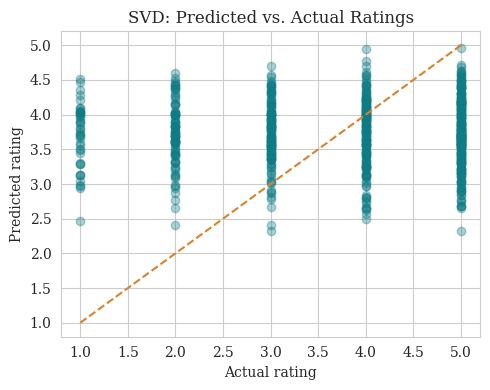

In [45]:
plt.figure(figsize=(5, 4))
plt.scatter(y_true, y_pred, alpha=0.35, color="#0E7C86")
plt.plot([1, 5], [1, 5], "--", color="#D9822B")
plt.xlabel("Actual rating"); plt.ylabel("Predicted rating")
plt.title("SVD: Predicted vs. Actual Ratings")
plt.tight_layout()
plt.savefig("../outputs/svd_predicted_vs_actual.png", dpi=120)
plt.show()

## Part 4 — Additional Variation: Item-Based Collaborative Filtering

As a third approach, we try **item-based** collaborative filtering instead of user-based.
Rather than asking "which users are similar to me?", it asks "which items tend to get
rated similarly to items I already liked?" Item-based similarity is usually more stable
than user-based similarity in practice, because item rating patterns tend to be more
consistent over time than any one user's preferences, and the item-item similarity matrix
doesn't need to be recomputed every time a new user joins.

In [46]:
item_item_sim = cosine_similarity(filled.T)
item_item_sim_df = pd.DataFrame(item_item_sim, index=user_item.columns, columns=user_item.columns)

def collaborative_recommend_item_based(user_id, top_n=5, k_neighbors=15):
    user_ratings = user_item.loc[user_id].dropna()
    scores = pd.Series(0.0, index=user_item.columns)
    weight_totals = pd.Series(0.0, index=user_item.columns)

    for rated_item, rating in user_ratings.items():
        sims = item_item_sim_df[rated_item]
        scores += sims * rating
        weight_totals += sims.abs()

    scores = (scores / weight_totals.replace(0, np.nan)).dropna()
    scores = scores.drop(index=user_ratings.index, errors="ignore").sort_values(ascending=False)

    top_ids = scores.head(top_n).index
    result = items[items["item_id"].isin(top_ids)][["item_id", "title", "category"]].copy()
    result["predicted_rating"] = scores.loc[top_ids].values
    return result.sort_values("predicted_rating", ascending=False)

collaborative_recommend_item_based(target_user, top_n=5)

,item_id,title,category,predicted_rating
21,22,Electric Kettle,Kitchen & Dining,3.583246
24,25,Glass Meal Prep Containers,Kitchen & Dining,3.576355
52,53,Fountain Pen Set,Office & Stationery,3.566669
53,54,Leather Notebook A5,Office & Stationery,3.559492
57,58,Desk Lamp LED Dimmable,Office & Stationery,3.558447


In [47]:
# Evaluate item-based CF with the same train/test split and RMSE metric as SVD
item_item_sim_train = cosine_similarity(train_filled.T)
item_item_sim_train_df = pd.DataFrame(item_item_sim_train, index=train_filled.columns, columns=train_filled.columns)

def predict_item_based(user_id, item_id):
    if user_id not in train_matrix.index or item_id not in item_item_sim_train_df.columns:
        return np.nan
    user_ratings = train_matrix.loc[user_id].dropna()
    if len(user_ratings) == 0:
        return np.nan
    sims = item_item_sim_train_df.loc[item_id, user_ratings.index]
    if sims.abs().sum() == 0:
        return user_means.get(user_id, ratings["rating"].mean())
    return float((sims * user_ratings).sum() / sims.abs().sum())

y_true_ib, y_pred_ib = [], []
for _, row in test_df.iterrows():
    pred = predict_item_based(row["user_id"], row["item_id"])
    if not np.isnan(pred):
        y_true_ib.append(row["rating"])
        y_pred_ib.append(np.clip(pred, 1, 5))

item_based_rmse = float(mean_squared_error(y_true_ib, y_pred_ib) ** 0.5)
print(f"Item-based CF RMSE on held-out ratings: {item_based_rmse:.3f}  (n={len(y_true_ib)})")

Item-based CF RMSE on held-out ratings: 1.319  (n=692)


## Part 5 — Evaluation and Model Comparison

### 5a. Quantitative: RMSE against a naive baseline

The simplest possible "model" is predicting the global average rating for every single
prediction, regardless of user or item. Any real model needs to beat this to be worth using.

In [48]:
# User-based CF, evaluated the same way as item-based: similarity computed from
# TRAINING ratings only, so no test-set information leaks into the similarity scores.
train_user_sim = cosine_similarity(train_filled)
train_user_sim_df = pd.DataFrame(train_user_sim, index=train_filled.index, columns=train_filled.index)

def predict_user_based(user_id, item_id, k_neighbors=15):
    if user_id not in train_matrix.index or item_id not in train_matrix.columns:
        return np.nan
    sims = train_user_sim_df.loc[user_id].drop(user_id).sort_values(ascending=False).head(k_neighbors)
    neighbor_ratings = train_matrix.loc[sims.index, item_id]
    valid = neighbor_ratings.notna()
    if valid.sum() == 0:
        return user_means.get(user_id, ratings["rating"].mean())
    return float((sims[valid] * neighbor_ratings[valid]).sum() / sims[valid].sum())

y_true_ub, y_pred_ub = [], []
for _, row in test_df.iterrows():
    pred = predict_user_based(row["user_id"], row["item_id"])
    if not np.isnan(pred):
        y_true_ub.append(row["rating"])
        y_pred_ub.append(np.clip(pred, 1, 5))

user_based_rmse = float(mean_squared_error(y_true_ub, y_pred_ub) ** 0.5)
print(f"User-based CF RMSE on held-out ratings: {user_based_rmse:.3f}  (n={len(y_true_ub)})")

User-based CF RMSE on held-out ratings: 1.440  (n=692)


In [49]:
naive_pred = train_df["rating"].mean()
y_true_naive = test_df["rating"].values
y_pred_naive = np.full_like(y_true_naive, naive_pred, dtype=float)
naive_rmse = float(mean_squared_error(y_true_naive, y_pred_naive) ** 0.5)

model_metrics = {
    "Naive (global average)": naive_rmse,
    "Collaborative - User-based": user_based_rmse,
    "Collaborative - SVD": svd_rmse,
    "Collaborative - Item-based": item_based_rmse,
}
for name, rmse in model_metrics.items():
    print(f"{name:30s} RMSE = {rmse:.3f}")

Naive (global average)         RMSE = 1.247
Collaborative - User-based     RMSE = 1.440
Collaborative - SVD            RMSE = 1.322
Collaborative - Item-based     RMSE = 1.319


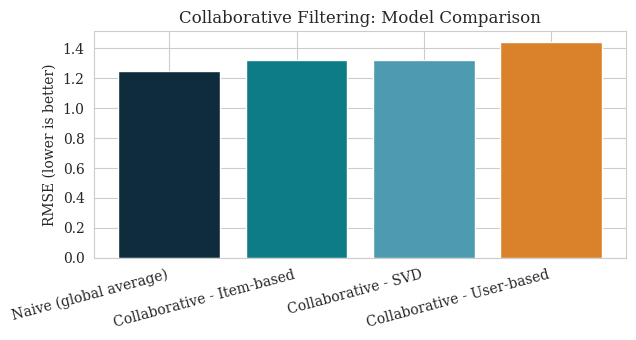

,Model,RMSE
0,Naive (global average),1.246616
1,Collaborative - Item-based,1.318767
2,Collaborative - SVD,1.321917
3,Collaborative - User-based,1.440137


In [50]:
comparison = pd.DataFrame({"Model": list(model_metrics.keys()), "RMSE": list(model_metrics.values())})
comparison = comparison.sort_values("RMSE").reset_index(drop=True)
comparison.to_csv("../outputs/model_comparison.csv", index=False)

plt.figure(figsize=(6.5, 3.5))
plt.bar(comparison["Model"], comparison["RMSE"], color=["#0F2C3D", "#0E7C86", "#4C9BB0", "#D9822B"])
plt.xticks(rotation=15, ha="right")
plt.ylabel("RMSE (lower is better)")
plt.title("Collaborative Filtering: Model Comparison")
plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", dpi=120)
plt.show()
comparison

### 5b. Qualitative: does content-based filtering make sense for real users?

Content-based filtering has no single "correct" rating to predict, so we check it
qualitatively instead: for a handful of users, does the recommended category match what
they've actually rated highly in the past?

In [51]:
def user_top_category(user_id):
    user_ratings = ratings[ratings["user_id"] == user_id].merge(items[["item_id", "category"]], on="item_id")
    return user_ratings.groupby("category")["rating"].mean().sort_values(ascending=False)

for uid in [1, 2, 3]:
    top_cats = user_top_category(uid)
    print(f"--- User {uid} ---")
    print("Average rating by category (their own history):")
    print(top_cats.round(2))

    # seed content-based filtering from this user's single highest-rated item
    user_ratings = ratings[ratings["user_id"] == uid].sort_values("rating", ascending=False)
    seed = user_ratings.iloc[0]
    seed_title = items.loc[items["item_id"] == seed["item_id"], "title"].values[0]
    print(f"Seeding from their top-rated item: {seed_title} (rated {seed['rating']})")
    recs = content_based_recommend(seed["item_id"], top_n=5)
    print("Content-based recommendations:")
    print(recs[["title", "category", "similarity"]].to_string(index=False))
    print()

--- User 1 ---
Average rating by category (their own history):
category
Tech & Gadgets       3.60
Outdoor & Camping    3.33
Name: rating, dtype: float64
Seeding from their top-rated item: Noise-Cancelling Headphones (rated 5)
Content-based recommendations:
                 title          category  similarity
  Wireless Earbuds Pro    Tech & Gadgets    0.367918
    Smart Fitness Band    Tech & Gadgets    0.120982
             4K Webcam    Tech & Gadgets    0.073419
Bluetooth Speaker Mini    Tech & Gadgets    0.072692
    Compact Binoculars Outdoor & Camping    0.069521

--- User 2 ---
Average rating by category (their own history):
category
Books & Media          4.14
Office & Stationery    2.00
Outdoor & Camping      2.00
Tech & Gadgets         1.00
Name: rating, dtype: float64
Seeding from their top-rated item: Graphic Novel: Steel Horizon (rated 5)
Content-based recommendations:
                       title      category  similarity
The Midnight Orchard (Novel) Books & Media    0.439

## Part 6 — Cold-Start Cases

The dataset includes two cases that naturally demonstrate the cold-start problem:
- **Item cold start:** item 60 (Laptop Stand Adjustable) has **zero ratings** — a brand-new product just added to the catalog.
- **User cold start:** user 300 has exactly **one rating** — a brand-new customer.

In [52]:
cold_item_id = 60
cold_item_title = items.loc[items["item_id"] == cold_item_id, "title"].values[0]
print(f"Item {cold_item_id} ({cold_item_title}) has {(ratings['item_id'] == cold_item_id).sum()} ratings in the dataset.")

print("\nContent-based CAN recommend it / recommend similar items for it immediately, using only its description:")
display_recs = content_based_recommend(cold_item_id, top_n=5)
print(display_recs[["title", "category", "similarity"]].to_string(index=False))

print("\nCollaborative filtering CANNOT include it in user-based or item-based recommendations at all --")
print("it has no ratings, so it has no row/column in the user-item matrix to compare against.")
print("Is item 60 in the user-item matrix columns?", cold_item_id in user_item.columns)

Item 60 (Laptop Stand Adjustable) has 0 ratings in the dataset.

Content-based CAN recommend it / recommend similar items for it immediately, using only its description:
                    title            category  similarity
   Ergonomic Office Chair Office & Stationery    0.319303
  Standing Desk Converter Office & Stationery    0.309468
    Desk Organizer Bamboo Office & Stationery    0.240430
 Wireless Mouse Ergonomic Office & Stationery    0.173912
Sticky Notes Variety Pack Office & Stationery    0.152105

Collaborative filtering CANNOT include it in user-based or item-based recommendations at all --
it has no ratings, so it has no row/column in the user-item matrix to compare against.
Is item 60 in the user-item matrix columns? False


In [53]:
cold_user_id = 300
n_cold_user_ratings = (ratings["user_id"] == cold_user_id).sum()
print(f"User {cold_user_id} has {n_cold_user_ratings} rating(s) in the dataset.")

print("\nCollaborative filtering CAN still attempt a recommendation (even from just 1 rating),")
print("by finding users who are similar based on that single shared rating:")
try:
    print(collaborative_recommend_user_based(cold_user_id, top_n=5))
except Exception as e:
    print("Failed:", e)

print("\nBut content-based filtering needs a seed item the user already liked --")
print("with only one rating, recommendations are only as good as that single data point,")
print("and with ZERO ratings, content-based filtering would have nothing to seed from at all.")

User 300 has 1 rating(s) in the dataset.

Collaborative filtering CAN still attempt a recommendation (even from just 1 rating),
by finding users who are similar based on that single shared rating:
    item_id                       title            category  predicted_rating
23       24        Knife Sharpening Set    Kitchen & Dining          5.000000
26       27         Coffee Grinder Burr    Kitchen & Dining          5.000000
34       35             Jump Rope Speed  Fitness & Wellness          5.000000
35       36      Massage Gun Percussion  Fitness & Wellness          4.512187
44       45  Beginner's Guide to Coding       Books & Media          4.493812

But content-based filtering needs a seed item the user already liked --
with only one rating, recommendations are only as good as that single data point,
and with ZERO ratings, content-based filtering would have nothing to seed from at all.


## Save all metrics for the report

In [54]:
all_results = {
    "naive_rmse": naive_rmse,
    "user_based_cf_rmse": user_based_rmse,
    "svd_rmse": svd_rmse,
    "item_based_cf_rmse": item_based_rmse,
    "n_test_ratings": len(test_df),
    "cold_start_item_id": cold_item_id,
    "cold_start_user_id": cold_user_id,
    "cold_start_user_n_ratings": int(n_cold_user_ratings),
}
with open("../outputs/all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print(json.dumps(all_results, indent=2))

{
  "naive_rmse": 1.2466157535427083,
  "user_based_cf_rmse": 1.4401372661820624,
  "svd_rmse": 1.3219169711339145,
  "item_based_cf_rmse": 1.3187670349794813,
  "n_test_ratings": 692,
  "cold_start_item_id": 60,
  "cold_start_user_id": 300,
  "cold_start_user_n_ratings": 1
}
